## 🚀 Graphiti: Temporal Knowledge Graphs for AI Agents

This notebook demonstrates **Graphiti**, a Python framework for building temporally-aware knowledge graphs designed for AI agents. Graphiti enables real-time incremental updates to knowledge graphs without batch recomputation, making it suitable for dynamic environments where relationships and information evolve over time.

### 🎯 What is Graphiti?

Graphiti is a powerful framework that creates dynamic, time-aware knowledge graphs from episodes (text or structured data). It automatically extracts entities, relationships, and facts while maintaining temporal context, making it perfect for AI applications that need to understand evolving information.

### 🌟 Key Features

- **⏰ Temporal Awareness** - Track when information was created, updated, or became invalid
- **📊 Real-time Updates** - Incremental graph building without full recomputation  
- **🧠 LLM Integration** - Smart entity and relationship extraction using modern language models
- **🔍 Hybrid Search** - Combine semantic, keyword, and graph-based retrieval
- **📈 Auto-scaling** - Efficient handling of large knowledge bases
- **🔗 Rich Relationships** - Complex entity relationships with temporal validity
- **🏘️ Community Detection** - Automatic grouping of related concepts

### 🛠️ Architecture Overview

This implementation uses:
- **🤖 Google Gemini** - For LLM operations (entity extraction, relationship inference)
- **📊 Neo4j** - As thea graph database for storage
- **🔧 Python** - Core framework and data processing
- **📈 NetworkX + Matplotlib** - For graph visualization

### 📋 Prerequisites

- ✅ Neo4j database instance (local or cloud)
- ✅ Google API key for Gemini models
- ✅ Python environment with required dependencies
- ✅ Basic understanding of knowledge graphs

---


## 🐳 Neo4j Database Setup

### 🚀 Launch Neo4j Docker Container

Set up a Neo4j instance using Docker with persistent data volumes for reliable memory storage:

```bash
docker run --name neo4j-container \
           -p 7474:7474 \
           -p 7687:7687 \
           -e NEO4J_AUTH=<your_username>/<your_password> \
           -v neo4j-data:/data \
           -v neo4j-logs:/logs \
           -d neo4j:latest 
```

### 🔗 Connection Configuration
- **🌐 Web Interface**: http://localhost:7474 (Neo4j Browser for query testing)
- **⚡ Bolt Protocol**: bolt://localhost:7687 (Application connection)
- **👤 Username**: <your_username>
- **🔐 Password**: <your_password>

### 📊 Verify Database Installation

After running the container:
1. Visit http://localhost:7474 in your browser
2. Login with the credentials above
3. Run a test query: `MATCH (n) OPTIONAL MATCH (n)-[r]->(m) RETURN n, r, m;` 
4. Ensure the connection is working before proceeding

### 🎯 Why Neo4j for Memory?

Neo4j is ideal for Mem0 because:
- **🔗 Native Graph Storage** - Optimized for relationship-heavy data
- **⚡ Fast Traversals** - Efficient memory retrieval across connections  
- **📊 ACID Compliance** - Reliable data consistency for memory operations
- **🔍 Cypher Query Language** - Powerful graph querying capabilities
- **📈 Scalability** - Handles growing memory graphs efficiently

### 📦 Dependencies Installation

Install all required packages for Graphiti graph operations:

In [ ]:
%pip install graphiti-core graphiti-core[google-genai] py2neo netgraph python-dotenv neo4j networkx matplotlib --upgrade


#### 📚 Package Overview

The installation includes:

- **`graphiti-core`** - Core Graphiti framework for temporal knowledge graphs
- **`graphiti-core[google-genai]`** - Google Gemini integration for LLM operations
- **`py2neo`** - Neo4j Python driver for graph database operations
- **`netgraph`** - Advanced graph visualization with interactive features
- **`python-dotenv`** - Environment variable management for secure config
- **`neo4j`** - Official Neo4j Python driver
- **`networkx`** - Graph data structures and algorithms
- **`matplotlib`** - Plotting and visualization backend

---


### ⚙️ Environment Configuration

Load environment variables and configure database connections. This setup uses a `.env` file for secure credential management.

#### 🔐 Required Environment Variables

Create a `.env` file in your project directory with:

```env
NEO4J_URL=bolt://localhost:7687
NEO4J_USERNAME=<your_username>  
NEO4J_PASSWORD=<your_password>
GOOGLE_API_KEY=<your_google_api_key>
```

#### 🛡️ Security Best Practices

- Never commit API keys or passwords to version control
- Use environment variables for all sensitive configuration
- Restrict database access to necessary IP ranges only
- Rotate API keys regularly for production deployments


In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

NEO4J_URL = os.getenv("NEO4J_URL")
NEO4J_USERNAME = os.getenv("NEO4J_USERNAME")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")


os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
os.environ["NEO4J_URL"] = NEO4J_URL
os.environ["NEO4J_USERNAME"] = NEO4J_USERNAME
os.environ["NEO4J_PASSWORD"] = NEO4J_PASSWORD

print("✅ Environment variables loaded successfully.")

✅ Environment variables loaded successfully.


---

### Graph Visualization Helper Function


In [2]:
from neo4j import GraphDatabase
import networkx as nx
import matplotlib.pyplot as plt
from netgraph import Graph as ngGraph


def display_graph():
    # Neo4j connection configuration
    uri = NEO4J_URL
    username = NEO4J_USERNAME
    password = NEO4J_PASSWORD

    # Connect to Neo4j
    driver = GraphDatabase.driver(uri, auth=(username, password))

    # Updated query to return node names
    query = """
    MATCH (n)
    OPTIONAL MATCH (n)-[r]->(m)
    RETURN n.name AS source_name, type(r) AS relationship_type, m.name AS target_name
    """

    # Function to execute the query and process results
    def get_graph_data(tx):
        result = tx.run(query)
        nodes = set()
        edges = []
        for record in result:
            source_name = record["source_name"]
            target_name = record["target_name"]
            relationship = record["relationship_type"]

            if source_name:
                nodes.add(source_name)
            if target_name:
                nodes.add(target_name)
                edges.append((source_name, target_name, relationship))

        return list(nodes), edges

    # Execute the query and get results
    with driver.session() as session:
        nodes, edges = session.execute_read(get_graph_data)

    # Create a NetworkX directed graph
    G = nx.DiGraph()

    # Add nodes and edges to the graph
    G.add_nodes_from(nodes)
    G.add_edges_from([(source, target, {'type': rel_type}) for source, target, rel_type in edges])

    # Set up the plot
    fig, ax = plt.subplots(figsize=(15, 12))
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    # Use netgraph for layout and drawing
    try:
        plot_instance = ngGraph(G, node_layout='spring', node_size=5, node_color='lightblue',
                        edge_width=0.4, edge_alpha=1, edge_color='black',
                        node_labels=True, edge_labels=nx.get_edge_attributes(G, 'type'),
                        arrows=True, ax=ax, arrowsize=1,
                        edge_arrow_width=0.5,
                        node_label_fontdict={'size': 12})
    except:
        plt.clf()
        plt.close(fig)
        ax.clear()
        plt.close('all')
        return "Nothing to Plot, add memories"

    plt.title("Graph Data Visualization", fontsize=20)

    # Enable zoom and pan
    def zoom_factory(ax, base_scale=2.):
        def zoom_fun(event):
            cur_xlim = ax.get_xlim()
            cur_ylim = ax.get_ylim()
            xdata = event.xdata
            ydata = event.ydata
            if event.button == 'up':
                scale_factor = 1/base_scale
            elif event.button == 'down':
                scale_factor = base_scale
            else:
                scale_factor = 1
            new_width = (cur_xlim[1] - cur_xlim[0]) * scale_factor
            new_height = (cur_ylim[1] - cur_ylim[0]) * scale_factor
            relx = (cur_xlim[1] - xdata)/(cur_xlim[1] - cur_xlim[0])
            rely = (cur_ylim[1] - ydata)/(cur_ylim[1] - cur_ylim[0])
            ax.set_xlim([xdata - new_width * (1-relx), xdata + new_width * (relx)])
            ax.set_ylim([ydata - new_height * (1-rely), ydata + new_height * (rely)])
            plt.draw()
        fig = ax.get_figure()
        fig.canvas.mpl_connect('scroll_event', zoom_fun)
        return zoom_fun

    zoom = zoom_factory(ax)

    def on_press(event):
        if event.inaxes != ax: return
        ax._pan_start = (event.x, event.y)

    def on_release(event):
        if event.inaxes != ax: return
        ax._pan_start = None

    def on_motion(event):
        if event.inaxes != ax: return
        if not ax._pan_start: return
        dx = event.x - ax._pan_start[0]
        dy = event.y - ax._pan_start[1]
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        scale_x = (xlim[1] - xlim[0]) / ax.get_window_extent().width
        scale_y = (ylim[1] - ylim[0]) / ax.get_window_extent().height
        ax.set_xlim(xlim - dx * scale_x)
        ax.set_ylim(ylim + dy * scale_y)
        ax._pan_start = (event.x, event.y)
        plt.draw()

    fig.canvas.mpl_connect('button_press_event', on_press)
    fig.canvas.mpl_connect('button_release_event', on_release)
    fig.canvas.mpl_connect('motion_notify_event', on_motion)

    plt.show()

    # Close the driver connection
    driver.close()
    
print("✅ Graph visualization helper function initialized successfully.")

✅ Graph visualization helper function initialized successfully.


---

### 🤖 Graphiti Client Initialization

Initialize the Graphiti framework with Google Gemini models for knowledge graph construction.

#### 🔧 Configuration Components

##### 🧠 LLM Client (GeminiClient)
- **Model**: `gemini-2.0-flash`
- **Purpose**: Entity extraction, relationship inference, and fact validation
- **Capabilities**: Natural language understanding, structured data processing

##### 📊 Embedder (GeminiEmbedder)  
- **Model**: `models/gemini-embedding-001`
- **Purpose**: Semantic similarity calculations and vector search
- **Output**: High-dimensional vectors for semantic operations

##### 🎯 Cross Encoder (GeminiRerankerClient)
- **Model**: `gemini-2.0-flash`
- **Purpose**: Result ranking and relevance scoring
- **Function**: Improves search result quality and precision


In [3]:
from graphiti_core import Graphiti
from graphiti_core.llm_client.gemini_client import GeminiClient, LLMConfig
from graphiti_core.embedder.gemini import GeminiEmbedder, GeminiEmbedderConfig
from graphiti_core.cross_encoder.gemini_reranker_client import GeminiRerankerClient


# Initialize Graphiti with Gemini clients
graphiti = Graphiti(
    uri=NEO4J_URL,
    user=NEO4J_USERNAME,
    password=NEO4J_PASSWORD,
    llm_client=GeminiClient(
        config=LLMConfig(
            api_key=GOOGLE_API_KEY,
            model="gemini-2.0-flash"
        )
    ),
    embedder=GeminiEmbedder(
        config=GeminiEmbedderConfig(
            api_key=GOOGLE_API_KEY,
            embedding_model="models/gemini-embedding-001"
        )
    ),
    cross_encoder=GeminiRerankerClient(
        config=LLMConfig(
            api_key=GOOGLE_API_KEY,
            model="gemini-2.0-flash"
        )
    )
)
print("✅ Graphiti client initialized successfully.")

✅ Graphiti client initialized successfully.


---

### 🏗️ Indices and constraints Initialization

Build the necessary indices and constraints in Neo4j for optimal Graphiti performance. This is a one-time setup operation.

#### 📋 What This Creates

- **🔍 Search Indices** - For fast entity and relationship lookups
- **⚡ Vector Indices** - For semantic similarity operations  
- **🔒 Constraints** - Data integrity and uniqueness enforcement
- **📊 Optimization** - Query performance improvements

#### 🎯 Performance Impact

Proper indexing provides:
- **Fast Queries** - Sub-second response times even with large graphs
- **Efficient Search** - Optimized semantic and keyword searches  
- **Data Integrity** - Prevents duplicate entities and malformed relationships
- **Scalability** - Maintains performance as graph grows

> **Note**: This only needs to be run once per database instance. Subsequent runs will update existing indices if needed.


In [4]:
# Initialize the graph database with graphiti's indices. This only needs to be done once.
try:
    await graphiti.build_indices_and_constraints()
    print("✅ Graph indices and constraints built successfully.")
except Exception as e:
    print(f"Error building indices and constraints: {e}")


✅ Graph indices and constraints built successfully.


---

### 📚 Episode Data: Building Knowledge from Diverse Sources

Episodes are the fundamental input units for Graphiti. They represent discrete pieces of information that can be processed into knowledge graph entities and relationships.

#### 🎯 Understanding Episodes

An **episode** in Graphiti is:
- A discrete piece of information with temporal context
- Can be text (natural language) or structured data (JSON)
- Associated with metadata like source, description, and timestamp
- Processed by LLMs to extract entities, relationships, and facts

#### 📊 Episode Types

##### 📝 Text Episodes
- **Content**: Natural language text
- **Processing**: NLP extraction of entities and relationships  
- **Use Cases**: News articles, transcripts, reports, conversations
- **Example**: Policy announcements, meeting notes, research papers

##### 🔢 JSON Episodes  
- **Content**: Structured data objects
- **Processing**: Direct mapping of fields to graph properties
- **Use Cases**: Database records, API responses, metadata
- **Example**: System logs, configuration data, metrics

#### 🔄 Processing Pipeline

Each episode goes through:
1. **📥 Ingestion** - Raw data input with metadata
2. **🧠 Analysis** - LLM processing for entity extraction  
3. **🔗 Relationship Mapping** - Connection identification
4. **⏰ Temporal Assignment** - Time-based validity periods
5. **📊 Graph Integration** - Merging with existing knowledge


In [5]:
from graphiti_core.nodes import EpisodeType
from datetime import datetime, timezone
import json

# Episodes list containing both text and JSON episodes
episodes = [
    {
        'content': 'The Digital India campaign was launched by Prime Minister Narendra Modi on '
                   'July 1, 2015, to transform India into a digitally empowered society and knowledge economy.',
        'type': EpisodeType.text,
        'description': 'policy announcement transcript',
    },
    {
        'content': 'Under Digital India, several initiatives such as Aadhaar, UPI, and DigiLocker '
                   'were expanded to improve access to public services through technology.',
        'type': EpisodeType.text,
        'description': 'program summary excerpt',
    },
    {
        'content': {
            'program': 'Digital India',
            'launched_by': 'Narendra Modi',
            'launch_date': '2015-07-01',
            'objectives': [
                'Digital infrastructure as a core utility to every citizen',
                'Governance and services on demand',
                'Digital empowerment of citizens',
            ],
        },
        'type': EpisodeType.json,
        'description': 'initiative metadata',
    },
    {
        'content': {
            'initiative': 'Unified Payments Interface (UPI)',
            'developed_by': 'National Payments Corporation of India (NPCI)',
            'launch_year': 2016,
            'impact': 'Enabled seamless digital transactions across banks in India',
            'transactions_2023': '118 billion',
        },
        'type': EpisodeType.json,
        'description': 'fintech infrastructure metadata',
    },
    {
        'content': 'India aims to achieve 500 GW of renewable energy capacity by 2030 under its '
                   'commitment to the Paris Agreement.',
        'type': EpisodeType.text,
        'description': 'energy policy announcement',
    },
    {
        'content': 'Adani Green Energy Limited and Tata Power are among the leading companies '
                   'contributing to India’s renewable energy capacity expansion.',
        'type': EpisodeType.text,
        'description': 'industry news excerpt',
    },
    {
        'content': {
            'organization': 'Adani Green Energy Limited',
            'sector': 'Renewable Energy',
            'projects': [
                {'type': 'Solar', 'capacity_GW': 8.5},
                {'type': 'Wind', 'capacity_GW': 2.3},
            ],
        },
        'type': EpisodeType.json,
        'description': 'corporate project metadata',
    },
    {
        'content': {
            'organization': 'Tata Power Renewable Energy Ltd',
            'sector': 'Renewable Energy',
            'target': {
                'year': 2030,
                'capacity_GW': 20,
            },
        },
        'type': EpisodeType.json,
        'description': 'corporate target metadata',
    },
    {
        'content': 'The Indian Space Research Organisation (ISRO) successfully launched Chandrayaan-3 '
                   'on July 14, 2023, marking India’s first successful soft landing on the lunar south pole.',
        'type': EpisodeType.text,
        'description': 'space mission report',
    },
    {
        'content': {
            'mission': 'Chandrayaan-3',
            'organization': 'ISRO',
            'launch_date': '2023-07-14',
            'achievement': 'First soft landing on lunar south pole',
            'status': 'Successful',
        },
        'type': EpisodeType.json,
        'description': 'mission metadata',
    },
]


print("✅ Episodes loaded successfully.")

✅ Episodes loaded successfully.


---

### 🔄 Real-time Knowledge Graph Construction

Process each episode sequentially to build the knowledge graph. Watch how entities and relationships emerge and evolve with each new piece of information.

#### ⚡ Live Processing Benefits

- **🔄 Incremental Updates** - No need for batch reprocessing
- **📊 Progressive Visualization** - See graph evolution in real-time
- **🎯 Entity Resolution** - Automatic merging of similar entities
- **⏰ Temporal Tracking** - Maintain historical context and validity periods

#### 🧠 What Happens During Processing

For each episode, Graphiti:

1. **🔍 Entity Extraction** - Identifies people, organizations, concepts, dates
2. **🔗 Relationship Discovery** - Finds connections between entities  
3. **📅 Temporal Contextualization** - Assigns validity periods based on content
4. **🔄 Graph Merging** - Integrates new information with existing knowledge
5. **📊 Fact Validation** - Ensures consistency and accuracy

#### 📈 Expected Graph Evolution

As episodes are processed, you'll observe:
- **👥 Entity Clustering** - Related entities group together naturally
- **🌐 Relationship Networks** - Complex interconnected structures emerge
- **⏰ Timeline Formation** - Temporal relationships become apparent
- **🏘️ Community Detection** - Thematic groupings develop organically

> **💡 Tip**: The `display_graph()` function after each episode shows the incremental knowledge building process!


Added episode: India Transformation Series 0 (text)


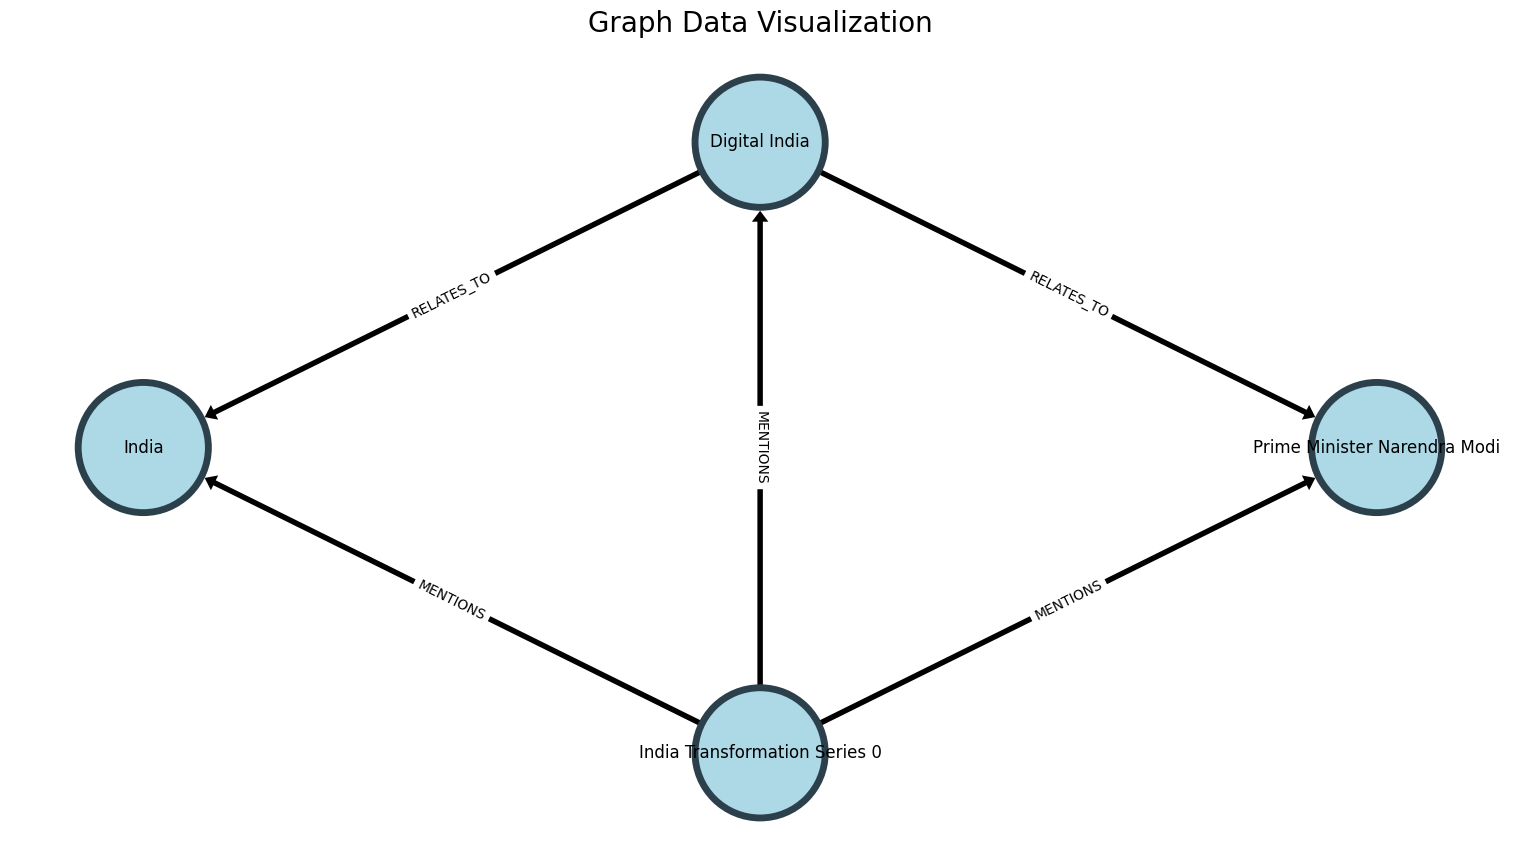

Added episode: India Transformation Series 1 (text)


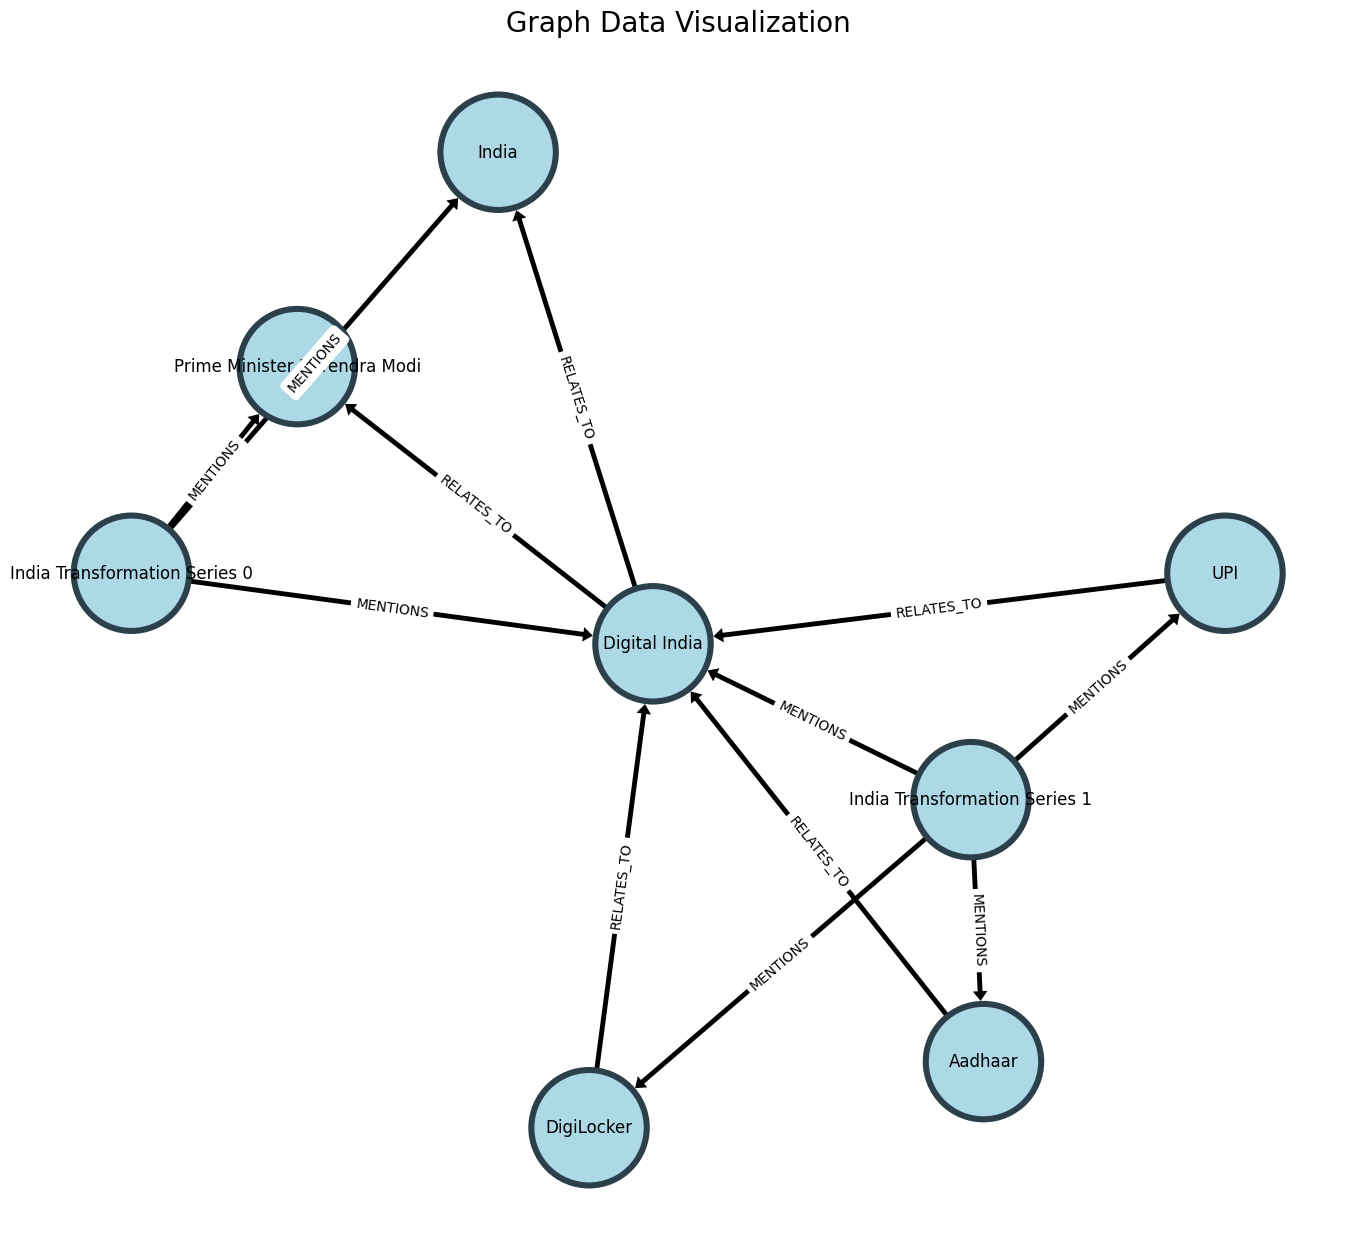

Added episode: India Transformation Series 2 (json)


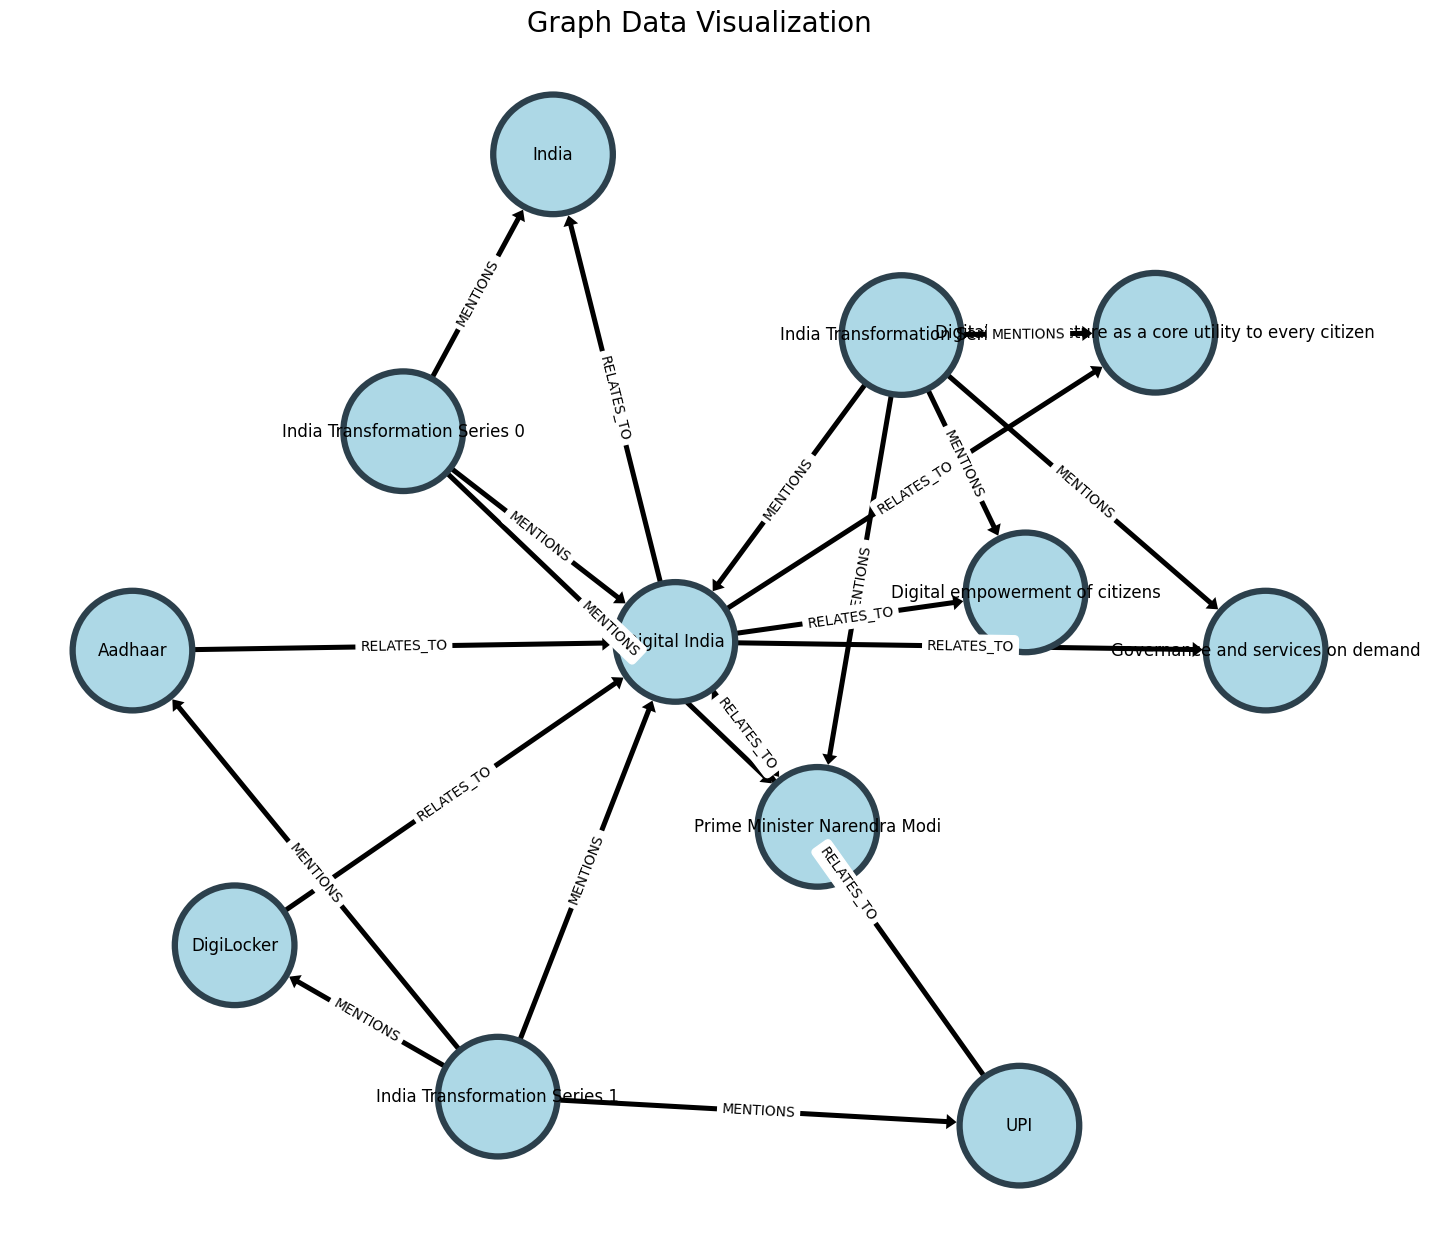

Added episode: India Transformation Series 3 (json)


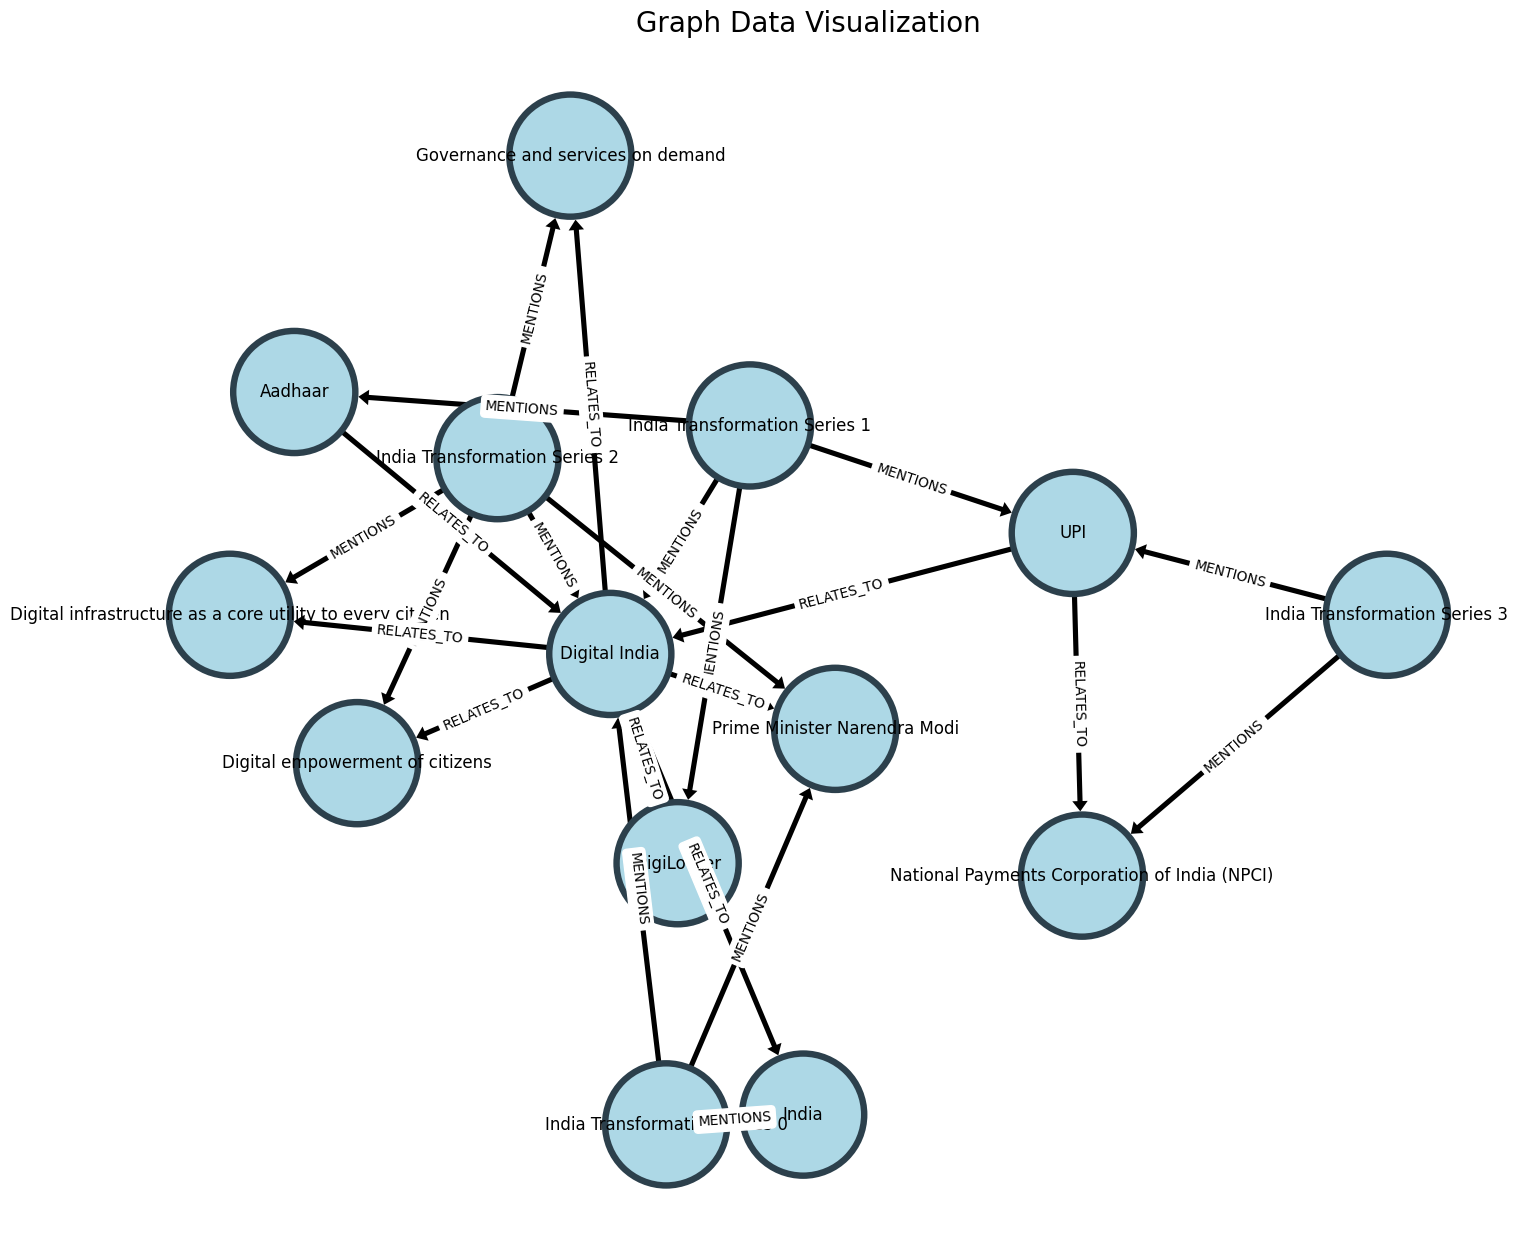

Added episode: India Transformation Series 4 (text)


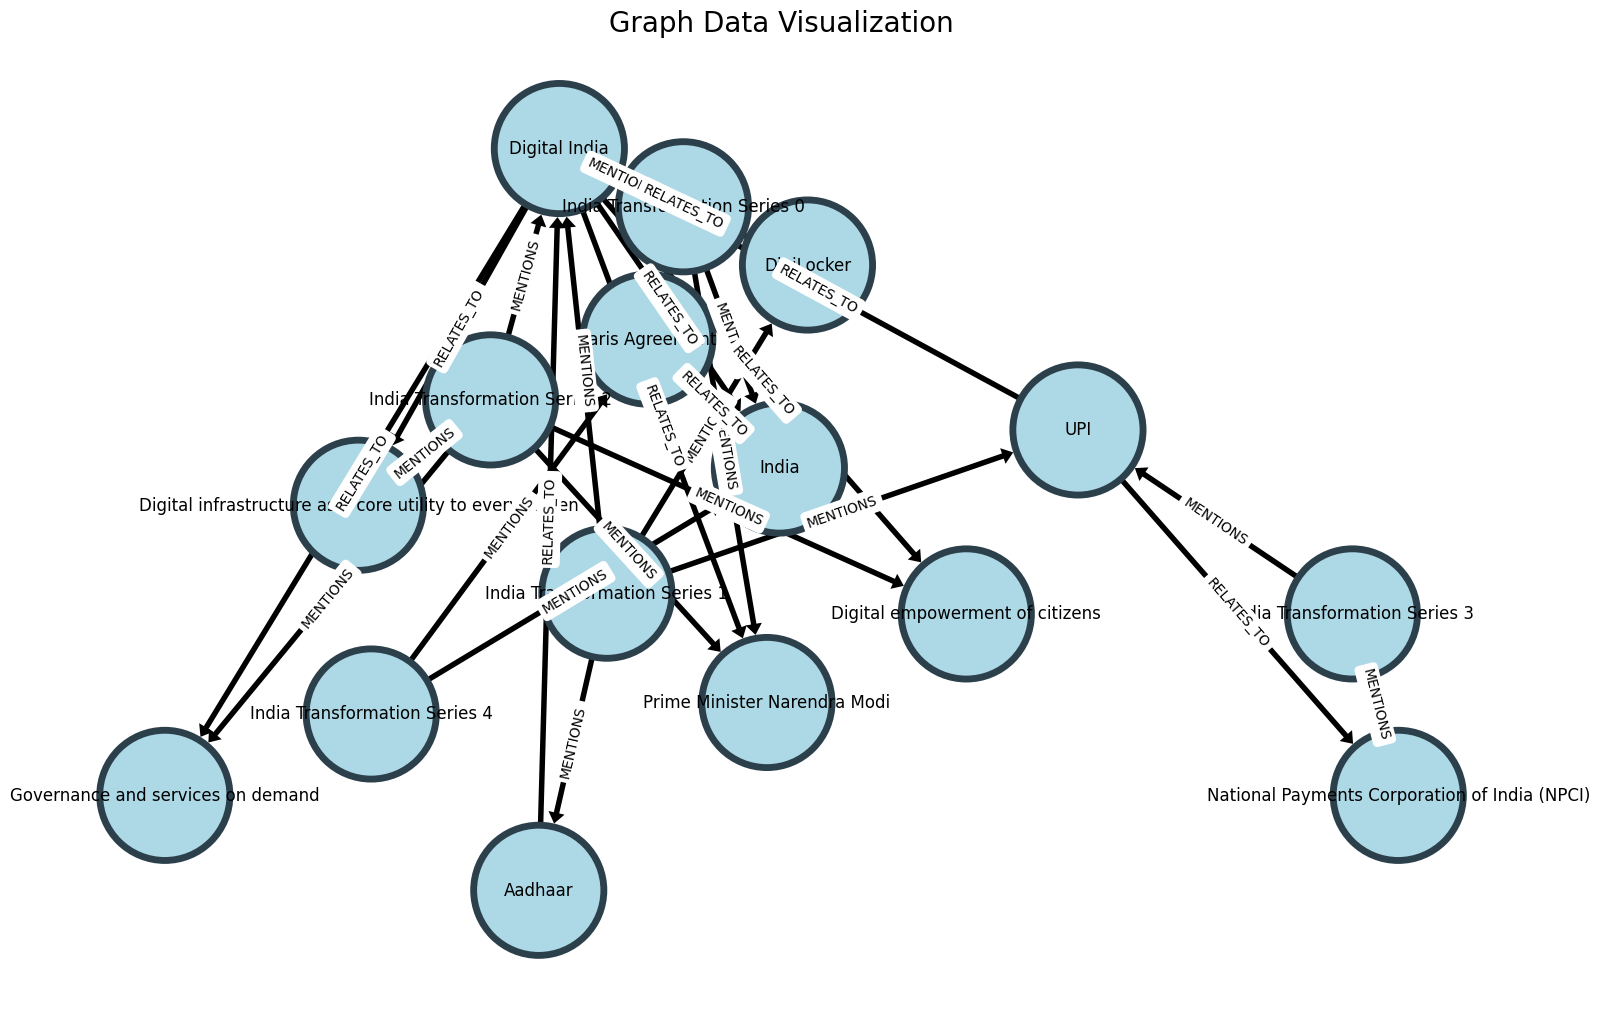

Added episode: India Transformation Series 5 (text)


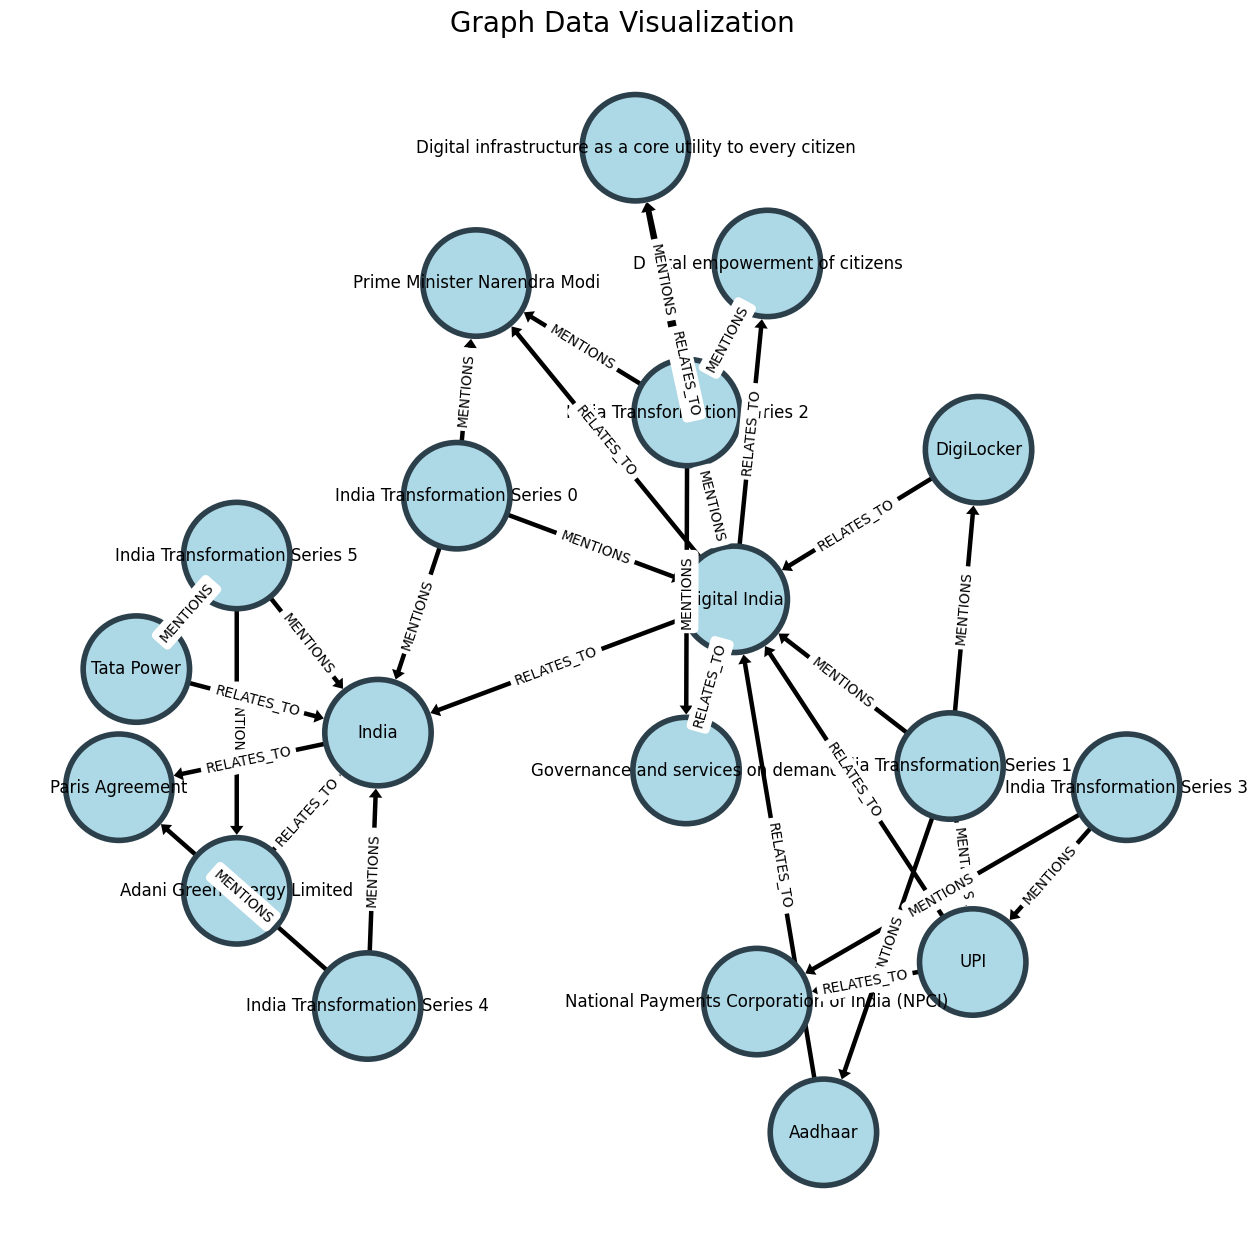

Added episode: India Transformation Series 6 (json)


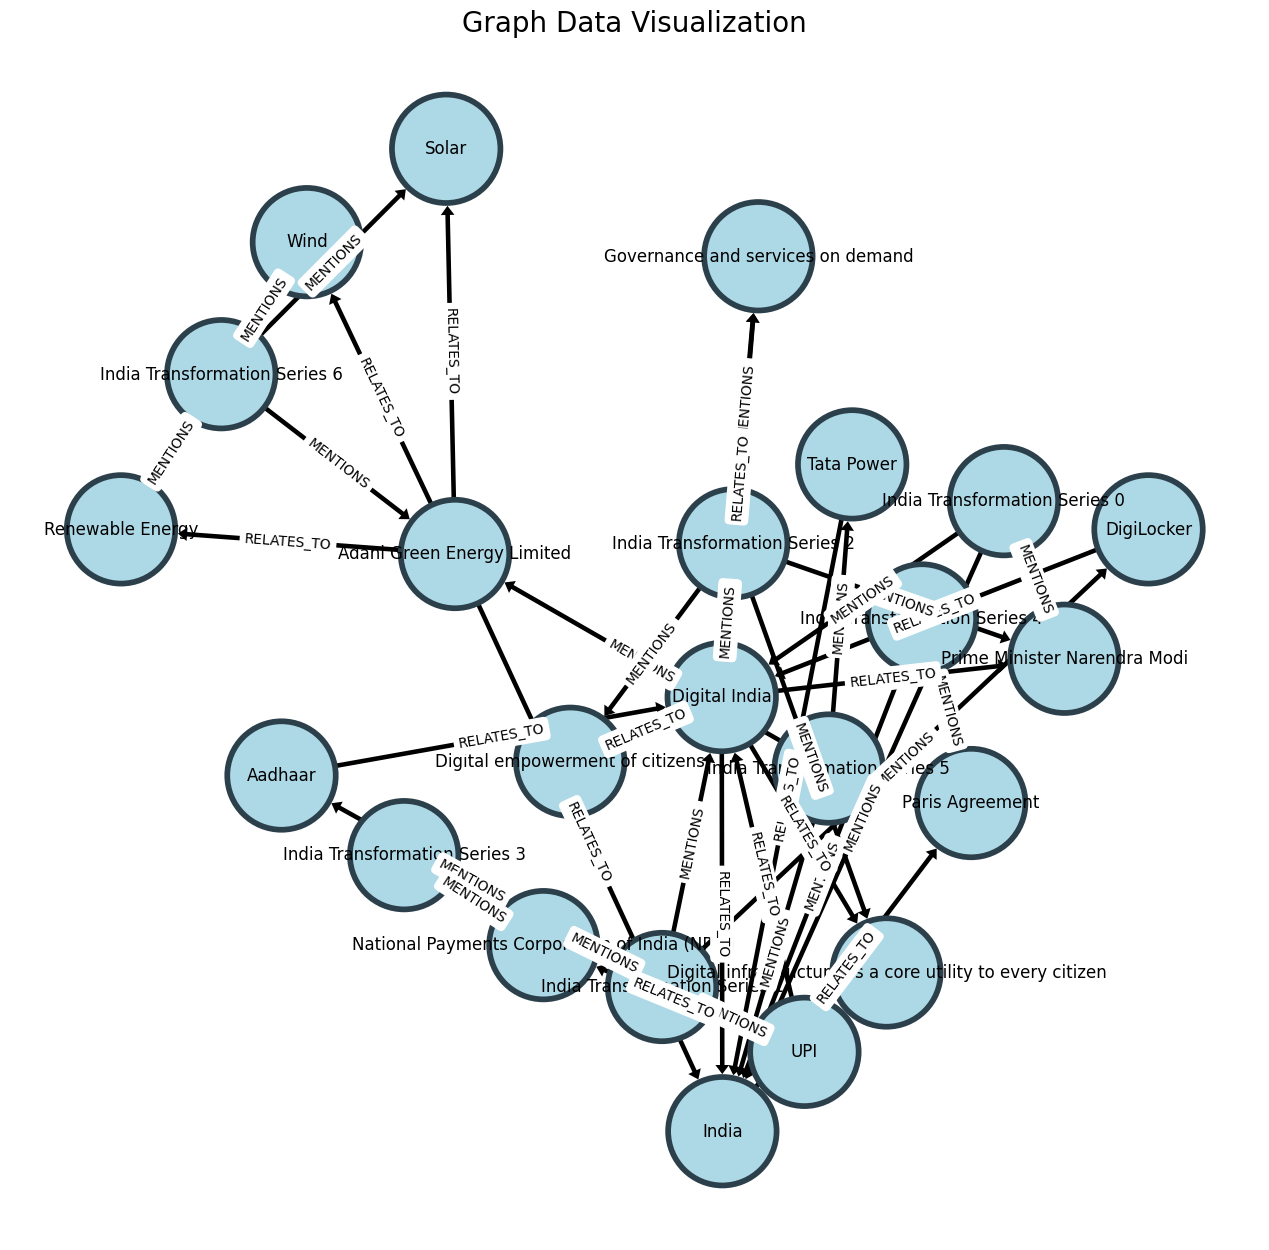

Added episode: India Transformation Series 7 (json)


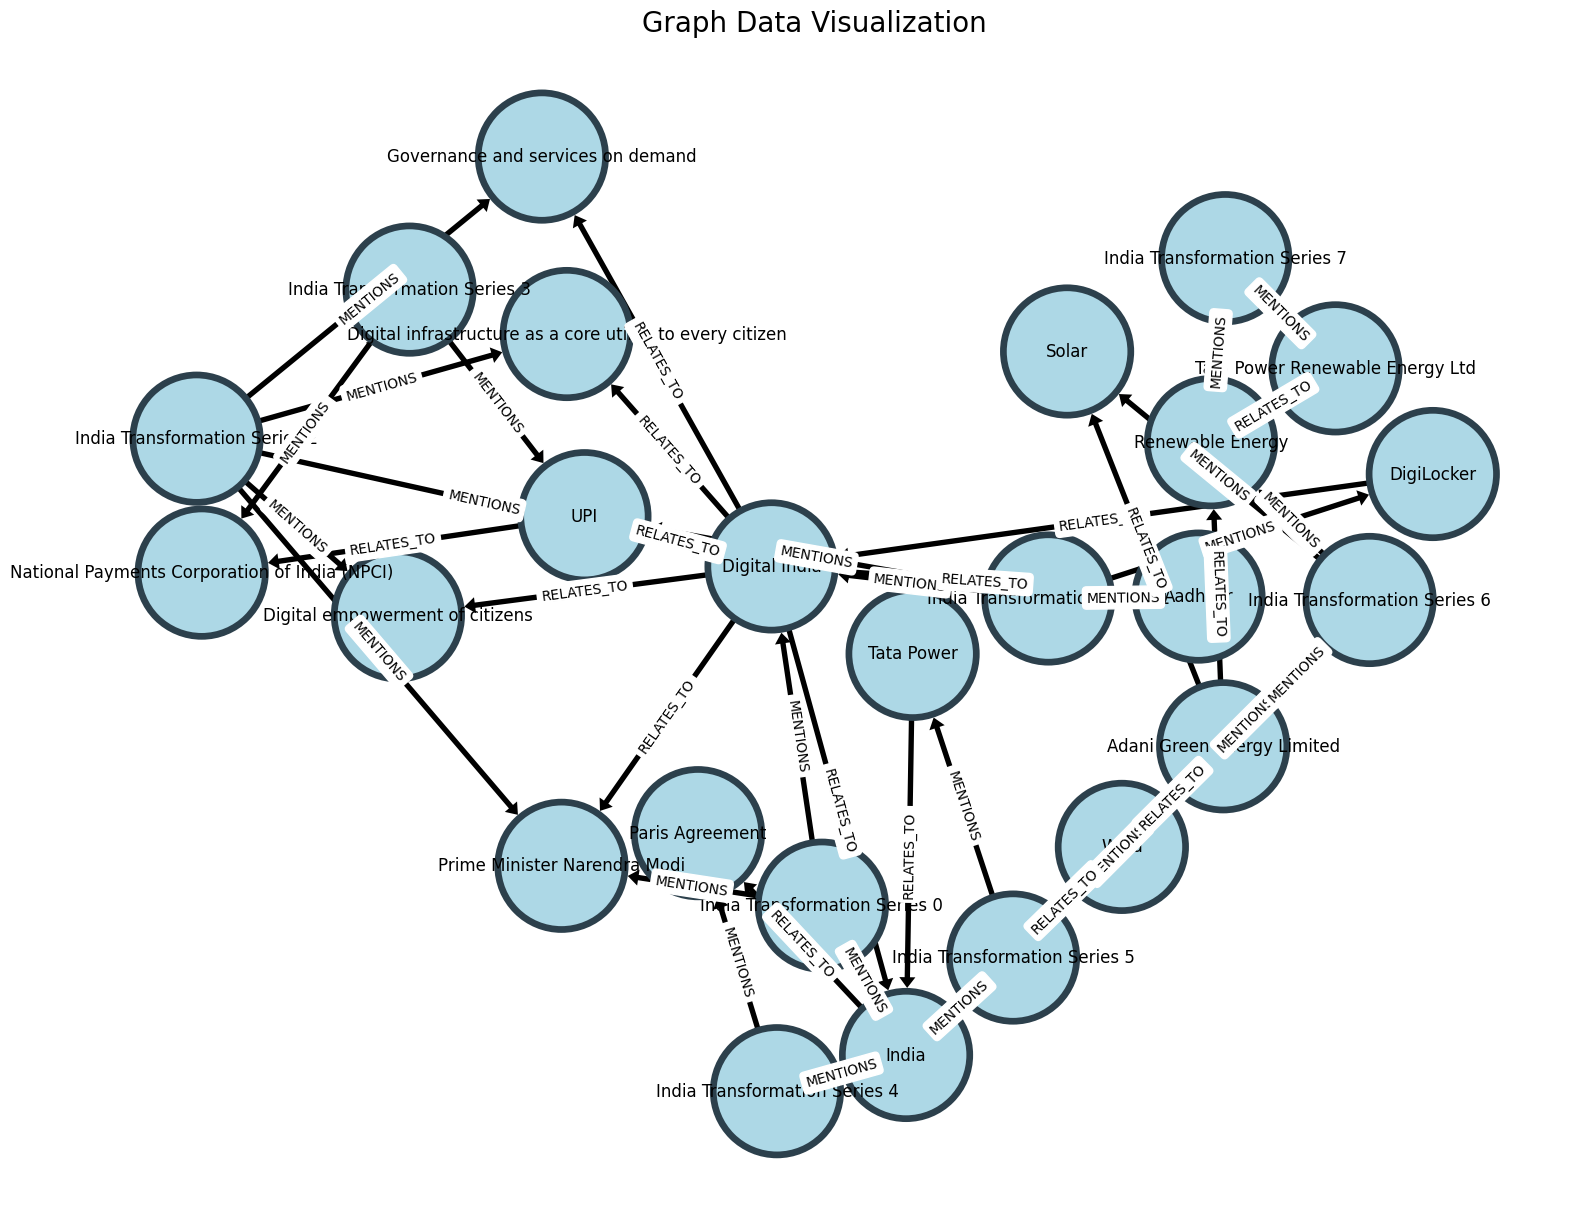

Added episode: India Transformation Series 8 (text)


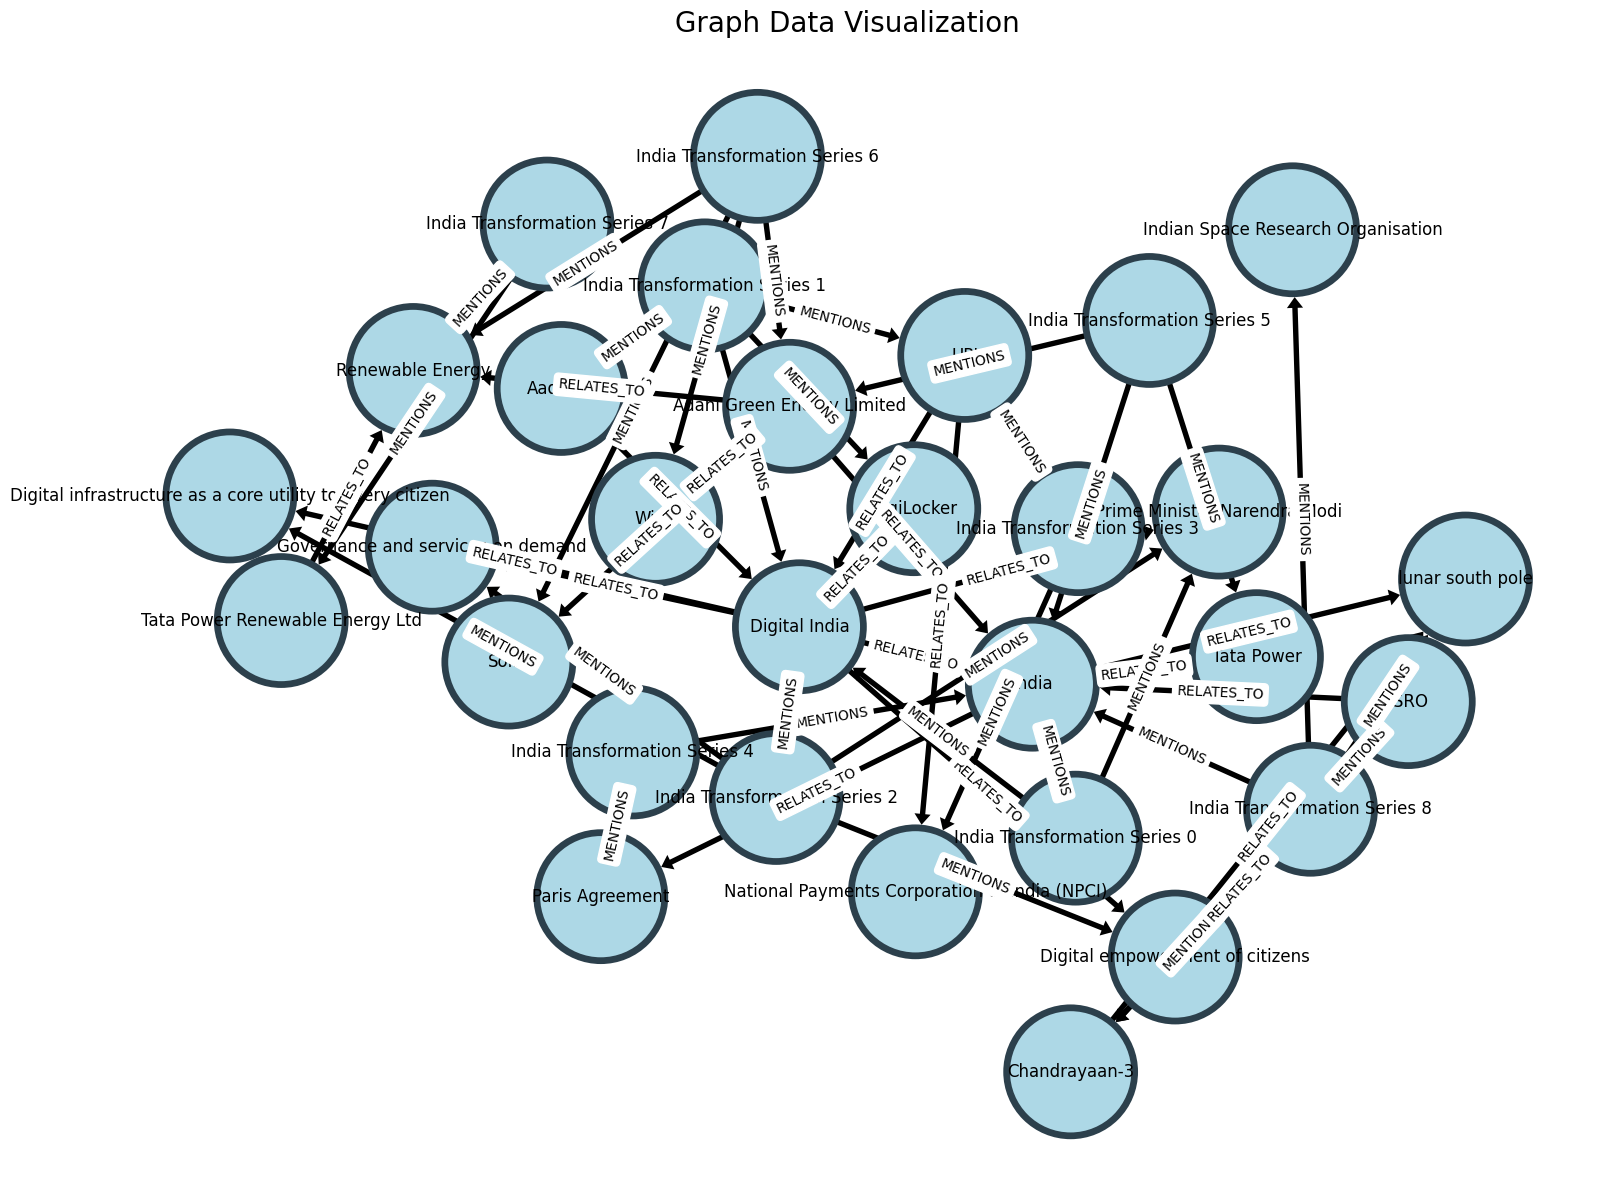

Added episode: India Transformation Series 9 (json)


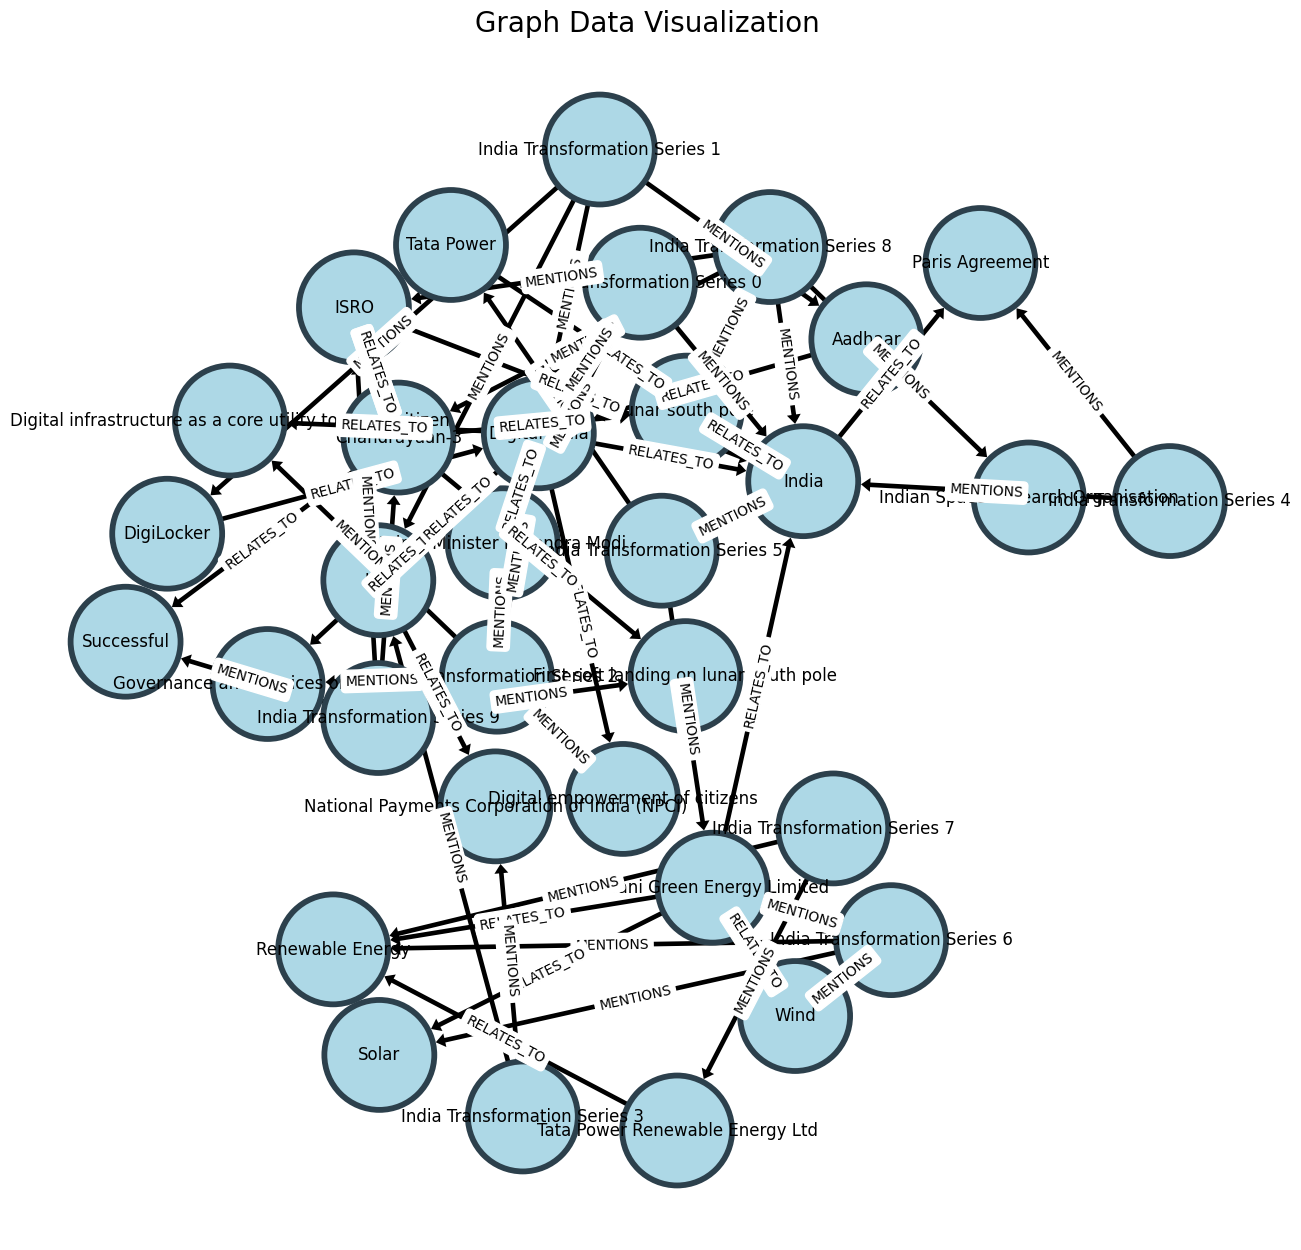

In [6]:
# Add episodes to the graph
for i, episode in enumerate(episodes):
    await graphiti.add_episode(
        name=f'India Transformation Series {i}',
        episode_body=episode['content']
        if isinstance(episode['content'], str)
        else json.dumps(episode['content']),
        source=episode['type'],
        source_description=episode['description'],
        reference_time=datetime.now(timezone.utc),
    )
    print(f'Added episode: India Transformation Series {i} ({episode["type"].value})')
    display_graph()

---

### 🔍 Intelligent Knowledge Retrieval

Demonstrate Graphiti's powerful search capabilities across different domains and query types. The hybrid search combines semantic understanding, keyword matching, and graph traversal.

#### 🎯 Search Capabilities

##### 🧠 **Semantic Search**
- Understanding query intent and context
- Finding conceptually related information
- Handling natural language variations

##### 🔤 **Keyword Matching**  
- Exact term matching for precision
- Entity name and property searches
- Structured data field queries

##### 📊 **Graph Traversal**
- Relationship-based discovery
- Multi-hop entity connections  
- Path finding between concepts



In [7]:
# 1️⃣  Query about Digital India
print("\nSearching for: 'Who launched the Digital India campaign?'")
results = await graphiti.search('Who launched the Digital India campaign?')

print('\nSearch Results:')
for result in results:
    print(f'UUID: {result.uuid}')
    print(f'Fact: {result.fact}')
    if hasattr(result, 'valid_at') and result.valid_at:
        print(f'Valid from: {result.valid_at}')
    if hasattr(result, 'invalid_at') and result.invalid_at:
        print(f'Valid until: {result.invalid_at}')
    print('---')




Searching for: 'Who launched the Digital India campaign?'

Search Results:
UUID: 805633a6-a6d2-4445-80b8-8ac7b3cb5a8e
Fact: The Digital India campaign was launched by Prime Minister Narendra Modi.
Valid from: 2015-07-01 00:00:00+00:00
---
UUID: 9df39788-8c93-4ea2-bbf5-afc286d8bcd0
Fact: The Digital India campaign aims to transform India into a digitally empowered society and knowledge economy.
Valid from: 2015-07-01 00:00:00+00:00
---
UUID: 52f53154-b6a1-46bf-99fa-2904a19dd12d
Fact: ISRO launched Chandrayaan-3.
Valid from: 2023-07-14 00:00:00+00:00
---
UUID: f76b777d-6bee-49ff-9499-b7b2f8bf3fb6
Fact: One objective of Digital India is digital infrastructure as a core utility to every citizen.
Valid from: 2015-07-01 00:00:00+00:00
---
UUID: 654a9812-d71c-43c0-a468-c39096779222
Fact: One objective of Digital India is digital empowerment of citizens.
Valid from: 2015-07-01 00:00:00+00:00
---
UUID: fde348d0-5505-4aac-921a-bf13f11adac4
Fact: Chandrayaan-3 was launched by ISRO.
Valid from: 2

In [8]:

# 2️⃣  Query about renewable energy goals
print("\nSearching for: 'What is India’s renewable energy target for 2030?'")
results = await graphiti.search('What is India’s renewable energy target for 2030?')

print('\nSearch Results:')
for result in results:
    print(f'UUID: {result.uuid}')
    print(f'Fact: {result.fact}')
    if hasattr(result, 'valid_at') and result.valid_at:
        print(f'Valid from: {result.valid_at}')
    if hasattr(result, 'invalid_at') and result.invalid_at:
        print(f'Valid until: {result.invalid_at}')
    print('---')


Searching for: 'What is India’s renewable energy target for 2030?'

Search Results:
UUID: c8343fdd-c6ae-4d03-bd7b-ea6f27d49abe
Fact: Adani Green Energy Limited contributes to India’s renewable energy capacity expansion.
Valid from: 2025-11-14 06:50:55.075249+00:00
---
UUID: 9213f002-0bb8-47f8-948d-092e9b0bab69
Fact: India aims to achieve 500 GW of renewable energy capacity by 2030 under its commitment to the Paris Agreement.
Valid from: 2025-11-14 06:50:44.638301+00:00
---
UUID: 03dc1789-30f8-43a9-a73c-5c29bd9765f1
Fact: Tata Power contributes to India’s renewable energy capacity expansion.
Valid from: 2025-11-14 06:50:55.075249+00:00
---
UUID: 5451e2d4-eb38-4915-a43b-8e8df98f79c3
Fact: Tata Power Renewable Energy Ltd is in the Renewable Energy sector.
---
UUID: ffd5b0ee-434d-47a9-86b8-2fd0477e9c93
Fact: Adani Green Energy Limited operates in the Renewable Energy sector.
---
UUID: 3eb27406-afe8-4308-ac0c-0272eb457942
Fact: ISRO is an Indian organization.
---
UUID: fbeb3520-bb94-4b4b-9

In [9]:
# 3️⃣  Query about space achievements
print("\nSearching for: 'Which Indian mission achieved the first soft landing on the lunar south pole?'")
results = await graphiti.search('Which Indian mission achieved the first soft landing on the lunar south pole?')

print('\nSearch Results:')
for result in results:
    print(f'UUID: {result.uuid}')
    print(f'Fact: {result.fact}')
    if hasattr(result, 'valid_at') and result.valid_at:
        print(f'Valid from: {result.valid_at}')
    if hasattr(result, 'invalid_at') and result.invalid_at:
        print(f'Valid until: {result.invalid_at}')
    print('---')


Searching for: 'Which Indian mission achieved the first soft landing on the lunar south pole?'

Search Results:
UUID: a357b727-737b-4e70-b71d-bc9ca172aa66
Fact: Chandrayaan-3 achieved first soft landing on lunar south pole.
Valid from: 2023-07-14 00:00:00+00:00
---
UUID: 6c80cf1c-22ec-4e9e-a3af-a6f31b288fc4
Fact: India had its first successful soft landing on the lunar south pole.
Valid from: 2023-07-14 00:00:00+00:00
---
UUID: aca652b9-738a-494c-8a0d-f031c6812076
Fact: Chandrayaan-3 successfully landed on the lunar south pole.
Valid from: 2023-07-14 00:00:00+00:00
---
UUID: 8b19e112-4bc2-4dd1-bf05-c8c535151798
Fact: The status of Chandrayaan-3 is successful.
Valid from: 2023-07-14 00:00:00+00:00
---
UUID: 3eb27406-afe8-4308-ac0c-0272eb457942
Fact: ISRO is an Indian organization.
---
UUID: 9df39788-8c93-4ea2-bbf5-afc286d8bcd0
Fact: The Digital India campaign aims to transform India into a digitally empowered society and knowledge economy.
Valid from: 2015-07-01 00:00:00+00:00
---
UUID

---

### 🏘️ Community Detection and Analysis

Build communities within the knowledge graph to identify clusters of related entities and concepts. This helps organize large graphs and discover hidden patterns.

#### 🎯 What are Communities?

Communities in Graphiti are:
- **👥 Entity Groups** - Clusters of highly connected entities
- **🌐 Thematic Areas** - Conceptually related topics  
- **📊 Structural Patterns** - Dense sub-graphs within the larger network
- **🔍 Discovery Tool** - Help identify relationships and insights

#### 🛠️ Community Detection Process

The algorithm:
1. **📊 Analyzes Connectivity** - Examines relationship density between entities
2. **🔍 Identifies Clusters** - Groups entities with strong interconnections  
3. **🏷️ Labels Communities** - Assigns meaningful names based on dominant themes
4. **📈 Calculates Metrics** - Community size, cohesion, and boundary strength


In [10]:
await graphiti.build_communities()


([CommunityNode(uuid='55454d2b-fda8-4ec8-ad49-8a0c18eed934', name="This summary highlights India's renewable energy goals, the Digital India initiative, and ISRO's Chandrayaan-3 lunar landing.", group_id='', labels=['Community'], created_at=datetime.datetime(2025, 11, 14, 6, 55, 16, 363002, tzinfo=datetime.timezone.utc), name_embedding=[-0.0071912184, -0.01651644, -0.024167284, -0.04685809, -0.0061773267, 0.0047586737, 0.03183252, 0.0067758905, 0.004413989, -0.02100899, -0.003972103, -0.0045020706, 0.006349339, 0.03829511, 0.12491634, 0.03283975, 0.009462488, -0.008249744, 0.025098622, -0.000786696, -0.0022385127, 0.0022489594, 0.0011085451, -0.028539008, -0.017982734, 0.0099907685, 0.00913121, 0.0033092373, 0.041646935, -0.0050944313, 0.0071660173, -0.0074973307, 0.016616754, 0.013332094, 0.0130927935, -0.006890645, 0.029295627, -7.73981e-05, 0.026308358, 0.013513247, -0.003815149, 0.019178994, -0.008623911, -0.012336052, -0.029629562, 0.0067314045, -0.009309819, -0.020405464, 0.00818

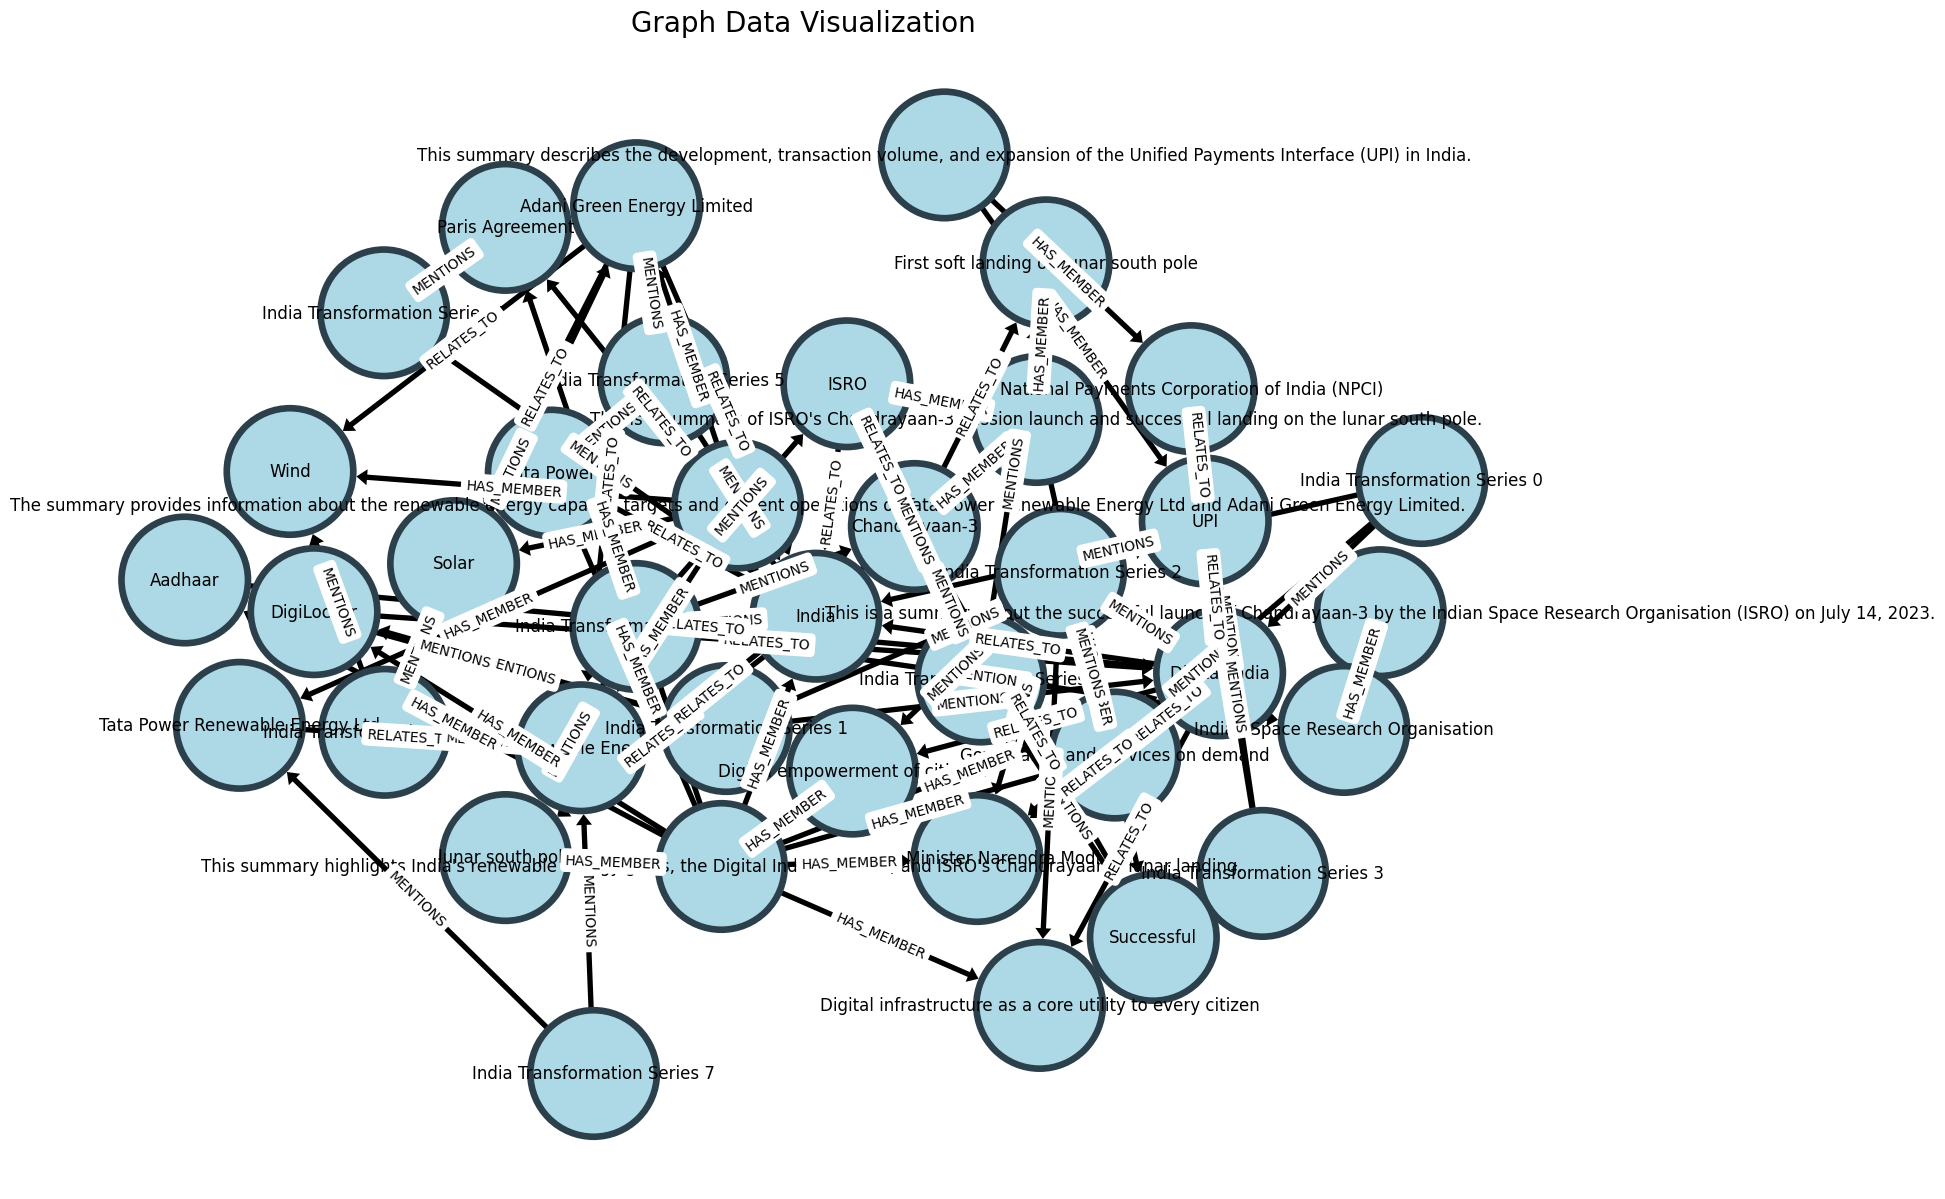

In [11]:
display_graph()

---

### 🎊 Final Graph Visualization

View the complete knowledge graph with all episodes processed and communities detected. This represents the full temporal knowledge network built from the India transformation episodes.

#### 🏆 Achievement Summary

Your Graphiti knowledge graph now includes:

✅ **Multiple Episode Types** - Both text and JSON data successfully processed  
✅ **Rich Entity Network** - People, organizations, policies, and achievements  
✅ **Temporal Relationships** - Time-aware facts with validity periods  
✅ **Cross-Domain Knowledge** - Technology, energy, space, and policy domains  
✅ **Community Structure** - Organized clusters of related concepts  
✅ **Search Capabilities** - Intelligent retrieval across all domains  

#### 🚀 Next Steps

**Extend the Graph:**
- Add more episodes from different time periods
- Include multimedia content (images, videos)
- Integrate real-time data feeds

**Advanced Operations:**
- Custom entity and relationship types
- Graph-based analytics and insights  
- Integration with AI agents and workflows

**Production Deployment:**
- Scale to larger datasets
- Implement caching and optimization
- Add user authentication and access control

#### 📚 Resources

- **📖 [Graphiti Documentation](https://help.getzep.com/graphiti)** - Complete guides and API reference
- **🐙 [GitHub Repository](https://github.com/getzep/graphiti)** - Source code and examples

---

🎉 **Congratulations!** You've successfully built and queried a temporal knowledge graph with Graphiti!
